In [1]:
import numpy as np

def load_rowland_sessions(npz_path):
    """Load sessions from the exported .npz file."""
    data = np.load(npz_path, allow_pickle=True)
    session_ids = data['session_ids']
    
    sessions = {}
    for sid in session_ids:
        prefix = f"session_{sid}_"
        sessions[sid] = {
            'signature': str(data[f'{prefix}signature']),
            'mouse': str(data[f'{prefix}mouse']),
            'run_number': int(data[f'{prefix}run_number']),
            'name': str(data[f'{prefix}name']),
            'filter_ps_time': data[f'{prefix}filter_ps_time'],
            'behaviour_trials': data[f'{prefix}behaviour_trials'],
            'is_target': data[f'{prefix}is_target'],
            'trial_subsets': data[f'{prefix}trial_subsets'],
            'n_cells': int(data[f'{prefix}n_cells']),
            'n_trials': int(data[f'{prefix}n_trials']),
            'n_times': int(data[f'{prefix}n_times']),
            's1_bool': data[f'{prefix}s1_bool'],
            's2_bool': data[f'{prefix}s2_bool'],
            'outcome': data[f'{prefix}outcome'],
            'frequency': float(data[f'{prefix}frequency']),
        }
    return sessions

sessions=load_rowland_sessions('/home/patriciobarber/AdaptiveLatents/workspace/datasets/rowland23/all_sessions.npz')

s0 = sessions[0]

In [2]:
# --- CORRECTION OF TIMING ---
# Shift timing so that t=0 is one timepoint earlier
time_axis = s0['filter_ps_time']
dt = time_axis[1] - time_axis[0]
print(f"Original Time Range: {time_axis.min():.4f} to {time_axis.max():.4f}")

# The user wants the current index for 0 to now be +dt (or rather, the index -1 is the new 0).
# If correct t=0 is one timepoint BEFORE current t=0:
# Current: ... t[-1]=-dt, t[0]=0, t[1]=dt ...
# New:     ... t[-1]=0,   t[0]=dt, ... (This shifts time array to the right? No.)

# "stimulus onset 1 timepoint before before what is currently indicated"
# Current 0 is at index `zero_idx`.
# We want index `zero_idx - 1` to be the new 0.
# So we need to ADD `dt` to the time axis? 
# If t[zero_idx] = 0, and we want t[zero_idx-1] = 0.
# Currently t[zero_idx-1] = -dt. 
# To make it 0, we add dt. 
# Then t[zero_idx] becomes dt.

s0['filter_ps_time'] = s0['filter_ps_time'] + dt
time_axis = s0['filter_ps_time']
zero_idx = np.argmin(np.abs(time_axis))

print(f"Corrected Time Range: {time_axis.min():.4f} to {time_axis.max():.4f}")
print(f"New Stimulus Onset Index: {zero_idx}, Time: {time_axis[zero_idx]:.4f}s")

Original Time Range: -7.9667 to 6.0000
Corrected Time Range: -7.9333 to 6.0333
New Stimulus Onset Index: 238, Time: -0.0000s


Input shape : (68040, 471)  (162 trials x 420 bins x 471 cells)
Sampling rate: 30.0 Hz
CUDA available: True
GPU: NVIDIA GeForce RTX 3060 Ti
Stim onset index: 238, t=-0.0000s
External variable shape (time-to-onset): (68040, 1)
time_offsets : 10 frames  (333 ms)

Fitting CEBRA (hybrid: time + stim-onset external variable) ...


behavior_pos:  0.9176 behavior_neg:  3.5176 behavior_total:  4.4352 time_pos:  0.3544 time_neg:  3.5176 time_total:  3.8720: 100%|██████████| 5000/5000 [02:07<00:00, 39.35it/s]


Embedding shape: (162, 420, 3)


/tmp/ipykernel_1797957/3216032672.py:105: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


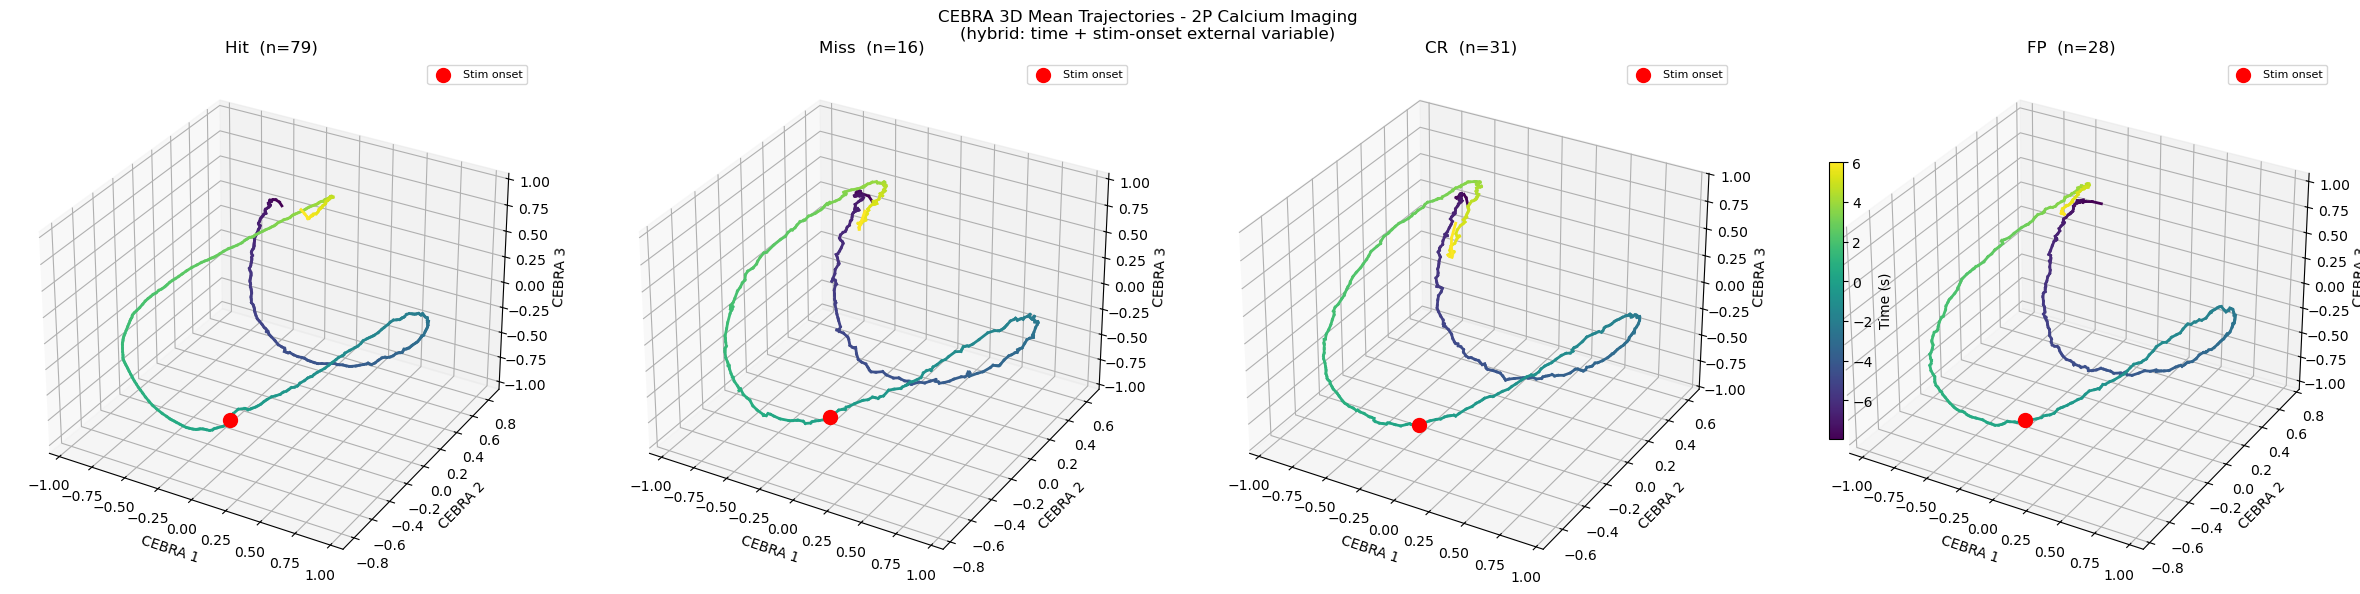

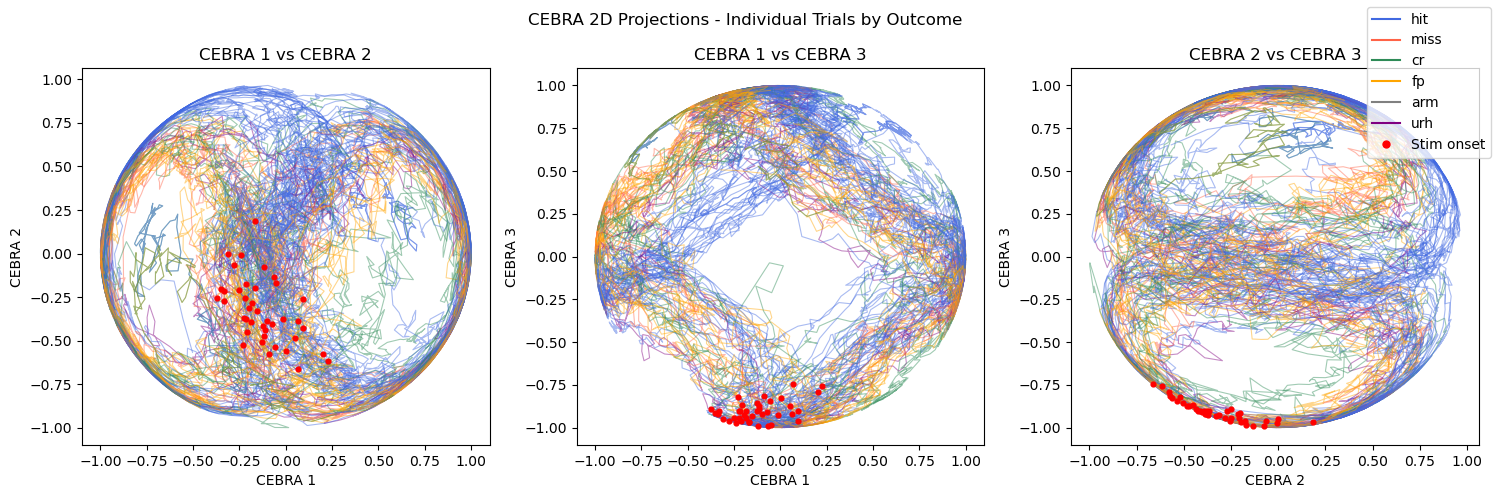

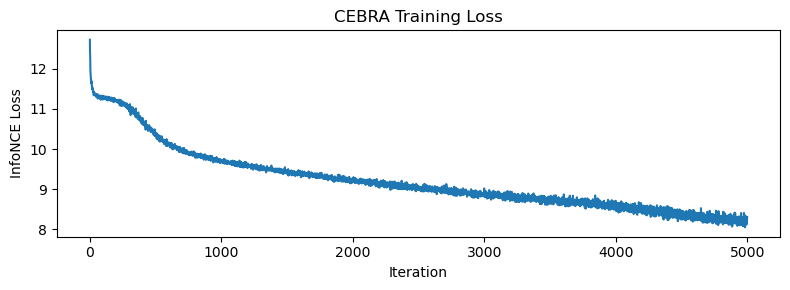

In [10]:
import cebra
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import zscore
import torch

# -- 1. Prepare data ---------------------------------------------------------
# behaviour_trials: (n_cells, n_trials, n_times)
neural_data = s0['behaviour_trials']          # (471, 162, 420)
n_cells, n_trials, n_times = neural_data.shape
freq = s0['frequency']                        # 30.0 Hz
time_axis = s0['filter_ps_time']              # (420,) seconds

# Reshape -> (total_time, n_cells) required by CEBRA
neural_2d = neural_data.transpose(1, 2, 0)                     # (n_trials, n_times, n_cells)
neural_flat = neural_2d.reshape(-1, n_cells).astype(np.float32)  # (n_trials*n_times, n_cells)

# Z-score each cell across all concatenated time -- standard for DeltaF/F calcium data
neural_flat = zscore(neural_flat, axis=0)
neural_flat = np.nan_to_num(neural_flat)  # replace NaN from zero-variance cells

print(f"Input shape : {neural_flat.shape}  ({n_trials} trials x {n_times} bins x {n_cells} cells)")
print(f"Sampling rate: {freq} Hz")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# -- 2. Build external variable for hybrid CEBRA ----------------------------
# External variable: signed time-to-stim-onset. Zero marks onset.
stim_idx = np.argmin(np.abs(time_axis))
rel_time_to_onset = (time_axis - time_axis[stim_idx]).astype(np.float32)       # (n_times,)
rel_time_external = np.tile(rel_time_to_onset[None, :], (n_trials, 1)).reshape(-1, 1)  # (total_time, 1)

print(f"Stim onset index: {stim_idx}, t={time_axis[stim_idx]:.4f}s")
print(f"External variable shape (time-to-onset): {rel_time_external.shape}")

# -- 3. Hybrid CEBRA hyperparameters ----------------------------------------
# offset10-model  : 10-frame causal ConvNet window (~333 ms at 30 Hz)
# conditional='time_delta': uses auxiliary variable geometry for positive pairs
# hybrid=True     : combines time-contrastive + behavior-contrastive objectives
time_offset_frames = int(round(0.33 * freq))  # ~10 frames ~333 ms
print(f"time_offsets : {time_offset_frames} frames  ({time_offset_frames / freq * 1000:.0f} ms)")

cebra_model = cebra.CEBRA(
    model_architecture='offset10-model',
    batch_size=512,
    learning_rate=3e-4,
    temperature_mode='auto',
    output_dimension=3,
    max_iterations=5000,
    distance='euclidean',
    conditional='time_delta',
    hybrid=True,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    verbose=True,
    time_offsets=time_offset_frames,
)

# -- 4. Fit & transform ------------------------------------------------------
print("\nFitting CEBRA (hybrid: time + stim-onset external variable) ...")
cebra_model.fit(neural_flat, rel_time_external)

embedding_flat = cebra_model.transform(neural_flat)      # (total_time, 3)
embedding = embedding_flat.reshape(n_trials, n_times, 3)  # (n_trials, n_times, 3)
print(f"Embedding shape: {embedding.shape}")

# outcome shape: (n_trials,) values: 'hit','miss','cr','fp','arm','urh'
outcome = s0['outcome']

# -- 5. Plot A - mean trajectory per behavioural outcome ---------------------
norm_t = plt.Normalize(time_axis.min(), time_axis.max())
cmap_t = plt.get_cmap('viridis')

# Focus on the four main outcomes
conditions = {
    'Hit': outcome == 'hit',
    'Miss': outcome == 'miss',
    'CR': outcome == 'cr',
    'FP': outcome == 'fp',
}
conditions = {k: v for k, v in conditions.items() if v.sum() > 0}  # drop empties
n_cond = len(conditions)

fig, axes = plt.subplots(1, n_cond, figsize=(6 * n_cond, 6), subplot_kw=dict(projection='3d'))
if n_cond == 1:
    axes = [axes]

for ax, (label, mask) in zip(axes, conditions.items()):
    mean_traj = embedding[mask].mean(axis=0)  # (n_times, 3)
    for i in range(n_times - 1):
        c = cmap_t(norm_t(time_axis[i]))
        ax.plot(mean_traj[i:i + 2, 0], mean_traj[i:i + 2, 1], mean_traj[i:i + 2, 2], color=c, linewidth=2)
    ax.scatter(*mean_traj[stim_idx], color='red', s=100, label='Stim onset', zorder=5)
    ax.set_title(f'{label}  (n={mask.sum()})')
    ax.set_xlabel('CEBRA 1')
    ax.set_ylabel('CEBRA 2')
    ax.set_zlabel('CEBRA 3')
    ax.legend(fontsize=8)

sm = plt.cm.ScalarMappable(cmap=cmap_t, norm=norm_t)
sm.set_array([])
fig.colorbar(sm, ax=axes, pad=0.04, shrink=0.6, label='Time (s)')
fig.suptitle('CEBRA 3D Mean Trajectories - 2P Calcium Imaging\n(hybrid: time + stim-onset external variable)', fontsize=12)
plt.tight_layout()
plt.show()

# -- 6. Plot B - 2-D projections, individual trials coloured by outcome ------
outcome_colors = {
    'hit': 'royalblue',
    'miss': 'tomato',
    'cr': 'seagreen',
    'fp': 'orange',
    'arm': 'gray',
    'urh': 'purple',
}

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
n_show = min(40, n_trials)
dim_pairs = [(0, 1), (0, 2), (1, 2)]
dim_labels = [('CEBRA 1', 'CEBRA 2'), ('CEBRA 1', 'CEBRA 3'), ('CEBRA 2', 'CEBRA 3')]

for ax, (d1, d2), (xl, yl) in zip(axes2, dim_pairs, dim_labels):
    for i in range(n_show):
        traj = embedding[i]
        col = outcome_colors.get(outcome[i], 'gray')
        ax.plot(traj[:, d1], traj[:, d2], color=col, alpha=0.45, linewidth=0.8)
        ax.scatter(traj[stim_idx, d1], traj[stim_idx, d2], color='red', s=12, zorder=5)
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(f'{xl} vs {yl}')

legend_elems = [
    Line2D([0], [0], color=c, label=k)
    for k, c in outcome_colors.items()
    if (outcome == k).sum() > 0
] + [
    Line2D([0], [0], marker='o', linestyle='None', color='red', markersize=5, label='Stim onset'),
]
fig2.legend(handles=legend_elems, loc='upper right')
fig2.suptitle('CEBRA 2D Projections - Individual Trials by Outcome', fontsize=12)
plt.tight_layout()
plt.show()

# -- 7. Training loss ---------------------------------------------------------
fig3, ax3 = plt.subplots(figsize=(8, 3))
ax3.plot(cebra_model.state_dict_['loss'])
ax3.set_xlabel('Iteration')
ax3.set_ylabel('InfoNCE Loss')
ax3.set_title('CEBRA Training Loss')
plt.tight_layout()
plt.show()

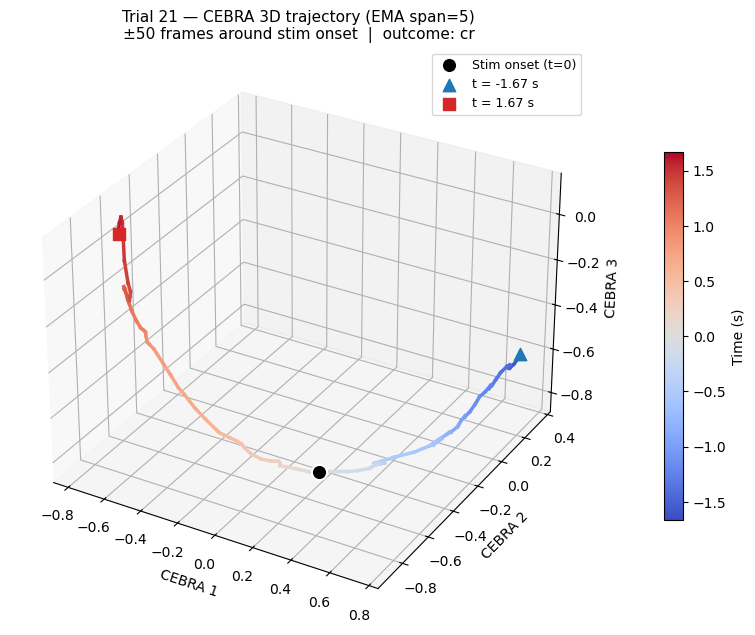

(<Figure size 800x700 with 2 Axes>,
 <Axes3D: title={'center': 'Trial 21 — CEBRA 3D trajectory (EMA span=5)\n±50 frames around stim onset  |  outcome: cr'}, xlabel='CEBRA 1', ylabel='CEBRA 2', zlabel='CEBRA 3'>)

In [12]:
import pandas as pd

def plot_cebra_trial(
    trial_idx,
    embedding,
    time_axis,
    outcome,
    stim_idx,
    half_win=50,
    ema_span=5,
    cmap='coolwarm',
    figsize=(8, 7),
    ax=None,
):
    """
    Plot a single trial's CEBRA 3D trajectory with EMA smoothing and a
    time-colour gradient.

    Parameters
    ----------
    trial_idx : int
        0-indexed trial number.
    embedding : ndarray, shape (n_trials, n_times, 3)
        CEBRA embedding.
    time_axis : ndarray, shape (n_times,)
        Time in seconds, with t=0 at stim onset.
    outcome : array-like, shape (n_trials,)
        Behavioural outcome labels.
    stim_idx : int
        Index of t=0 in time_axis.
    half_win : int
        Half-window size in frames (default 50).
    ema_span : int
        EMA span for smoothing (default 5 ≈ 167 ms at 30 Hz).
    cmap : str
        Matplotlib colormap name (default 'coolwarm').
    figsize : tuple
        Figure size, used only when ax is None.
    ax : Axes3D or None
        Pass an existing 3-D axis to embed in a larger figure.

    Returns
    -------
    fig, ax
    """
    t_start_w = stim_idx - half_win
    t_end_w   = stim_idx + half_win + 1

    traj_raw = embedding[trial_idx, t_start_w:t_end_w, :]   # (window, 3)
    t_win    = time_axis[t_start_w:t_end_w]                  # (window,) s

    # EMA smoothing along the time axis
    traj = pd.DataFrame(traj_raw).ewm(span=ema_span, adjust=False).mean().values

    norm_w = plt.Normalize(t_win.min(), t_win.max())
    cmap_w = plt.get_cmap(cmap)

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=figsize, subplot_kw=dict(projection='3d'))
    else:
        fig = ax.get_figure()

    # Colour-coded segments
    for i in range(len(t_win) - 1):
        c = cmap_w(norm_w(t_win[i]))
        ax.plot(traj[i:i+2, 0], traj[i:i+2, 1], traj[i:i+2, 2],
                color=c, linewidth=2.5)

    # Stim onset
    ax.scatter(*traj[half_win], color='black', s=120, zorder=6,
               edgecolors='white', linewidths=1.5, label='Stim onset (t=0)')

    # Start / end markers
    ax.scatter(*traj[0],  color='tab:blue', s=80, marker='^',
               label=f't = {t_win[0]:.2f} s')
    ax.scatter(*traj[-1], color='tab:red',  s=80, marker='s',
               label=f't = {t_win[-1]:.2f} s')

    # Colourbar
    sm = plt.cm.ScalarMappable(cmap=cmap_w, norm=norm_w)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, shrink=0.55, pad=0.1, label='Time (s)')

    ax.set_title(
        f'Trial {trial_idx + 1} — CEBRA 3D trajectory (EMA span={ema_span})\n'
        f'±{half_win} frames around stim onset  |  outcome: {outcome[trial_idx]}',
        fontsize=11,
    )
    ax.set_xlabel('CEBRA 1')
    ax.set_ylabel('CEBRA 2')
    ax.set_zlabel('CEBRA 3')
    ax.legend(fontsize=9)

    if own_fig:
        plt.tight_layout()
        plt.show()

    return fig, ax


# ── Example usage ──────────────────────────────────────────────────────────────
plot_cebra_trial(20, embedding, time_axis, outcome, stim_idx)


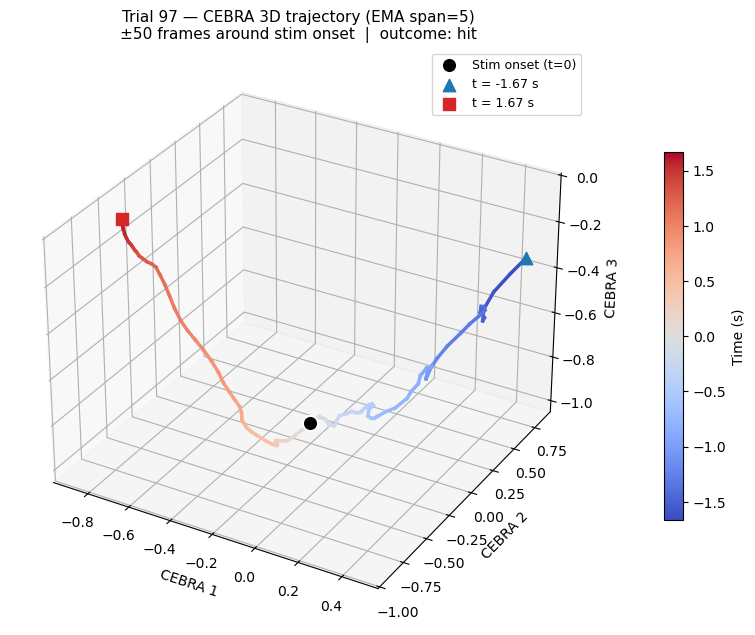

(<Figure size 800x700 with 2 Axes>,
 <Axes3D: title={'center': 'Trial 97 — CEBRA 3D trajectory (EMA span=5)\n±50 frames around stim onset  |  outcome: hit'}, xlabel='CEBRA 1', ylabel='CEBRA 2', zlabel='CEBRA 3'>)

In [13]:
# Trial number 97 (1-indexed) -> trial_idx 96 (0-indexed)
plot_cebra_trial(96, embedding, time_axis, outcome, stim_idx)

## GRU Forecasting in CEBRA Space with Strict Train/Test Split

To avoid data leakage, we perform an 80/20 train-test split over trials. We then:
1. Z-score the entire dataset using **only** the mean and standard deviation of the training set.
2. Fit the CEBRA model strictly on the **training set**.
3. Transform both the training and test sets into the learned CEBRA subspace.

Finally, we apply a trailing Exponential Moving Average (EMA) to smooth the discrete trajectories, and train a vanilla GRU (matching the one used in `RNNs.ipynb`) to forecast post-onset trajectories conditioned on the stimulation vector.

In [11]:
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import time
from sklearn.metrics import mean_squared_error, r2_score

# -- 1. Data Split (80/20) ---------------------------------------------------
all_indices = np.arange(n_trials)
train_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.2,
    random_state=42,
    shuffle=True,
)
train_indices = np.sort(train_indices)
test_indices = np.sort(test_indices)

print(f"Data Split: {len(train_indices)} Training trials, {len(test_indices)} Test trials")

# -- 2. Z-score using strictly training statistics ---------------------------
# neural_data is (n_cells, n_trials, n_times)
neural_2d_split = neural_data.transpose(1, 2, 0)  # (n_trials, n_times, n_cells)
train_data = neural_2d_split[train_indices]       # (n_train, n_times, n_cells)

train_flat = train_data.reshape(-1, n_cells).astype(np.float32)
train_mean = train_flat.mean(axis=0)
train_std = train_flat.std(axis=0)
train_std[train_std == 0] = 1.0  # Safe division

neural_2d_scaled = (neural_2d_split - train_mean) / train_std
neural_2d_scaled = np.nan_to_num(neural_2d_scaled)

train_flat_scaled = neural_2d_scaled[train_indices].reshape(-1, n_cells).astype(np.float32)

# -- 3. Build train-only external variable for hybrid CEBRA ------------------
# Signed time-to-onset as external variable, aligned with flattened train samples.
rel_time_to_onset = (time_axis - time_axis[zero_idx]).astype(np.float32)            # (n_times,)
rel_time_all = np.tile(rel_time_to_onset[None, :], (n_trials, 1))                    # (n_trials, n_times)
rel_time_train_flat = rel_time_all[train_indices].reshape(-1, 1).astype(np.float32)  # (n_train*n_times, 1)

print(f"External variable (train) shape: {rel_time_train_flat.shape}")

# -- 4. Refit CEBRA on training data only ------------------------------------
print(f"Refitting HYBRID CEBRA on TRAIN set only ({len(train_indices)} trials) to avoid data leakage...")

cebra_model_strict = cebra.CEBRA(
    model_architecture='offset10-model',
    batch_size=512,
    learning_rate=3e-4,
    temperature_mode='auto',
    output_dimension=3,
    max_iterations=5000,
    distance='euclidean',
    conditional='time_delta',
    hybrid=True,
    device='cuda' if torch.cuda.is_available() else 'cpu',
    verbose=True,
    time_offsets=time_offset_frames,
)

cebra_model_strict.fit(train_flat_scaled, rel_time_train_flat)

# -- 5. Transform all trials into the strict subspace -------------------------
all_flat_scaled = neural_2d_scaled.reshape(-1, n_cells).astype(np.float32)
embedding_flat_strict = cebra_model_strict.transform(all_flat_scaled)
embedding_strict = embedding_flat_strict.reshape(n_trials, n_times, 3)


z_trial = embedding_strict  # Shape: (n_trials, T, d_z=3)
print(f"Subspace extraction complete. z_trial shape: {z_trial.shape}")

Data Split: 129 Training trials, 33 Test trials
External variable (train) shape: (54180, 1)
Refitting HYBRID CEBRA on TRAIN set only (129 trials) to avoid data leakage...


behavior_pos:  0.5469 behavior_neg:  4.5102 behavior_total:  5.0571 time_pos:  0.1125 time_neg:  4.5102 time_total:  4.6227:  22%|██▏       | 1106/5000 [00:27<01:36, 40.24it/s]


KeyboardInterrupt: 

In [7]:
# --- 5. EMA Smoothing and Dataset Preparation ---

EMA_ALPHA = 0.2

def apply_ema(z, alpha=EMA_ALPHA):
    """Apply exponential moving average along the time axis."""
    out = np.empty_like(z)
    out[:, 0, :] = z[:, 0, :]
    for t in range(1, z.shape[1]):
        out[:, t, :] = alpha * z[:, t, :] + (1 - alpha) * out[:, t - 1, :]
    return out

z_trial = apply_ema(z_trial, alpha=EMA_ALPHA)
print(f"Applied EMA smoothing (alpha={EMA_ALPHA}) to CEBRA trajectories")

# Full stimulation vector over time (trial, time, neuron)
v = np.transpose(s0['is_target'], (1, 2, 0)).astype(np.float32)  # (n_trials, T, n_cells)

n_trials_total, T_total, d_z = z_trial.shape
n_cells_v = v.shape[-1]

# Forecast setup
horizon = 20
context_len = zero_idx + 1  # primed <= onset 
assert context_len > 1, "Need at least 2 context steps."
assert zero_idx + 1 + horizon <= T_total, "Not enough post-onset steps."

# Normalization from training split
z_train = z_trial[train_indices]
z_mean_c = z_train.mean(axis=(0, 1), keepdims=True)
z_std_c = z_train.std(axis=(0, 1), keepdims=True) + 1e-6
z_trial_n = (z_trial - z_mean_c) / z_std_c

# Variance contribution weights per latent component (from train set)
component_var = z_train.var(axis=(0, 1))
component_weights = component_var / (component_var.sum() + 1e-12)

print(f"context_len={context_len}, horizon={horizon}, d_z={d_z}, n_cells={n_cells_v}")

class OnsetForecastDataset(Dataset):
    def __init__(self, trial_indices):
        self.trial_indices = np.array(trial_indices)
    def __len__(self):
        return len(self.trial_indices)
    def __getitem__(self, idx):
        tr = self.trial_indices[idx]
        context_z = z_trial_n[tr, :context_len, :]                           
        context_v = v[tr, :context_len, :]
        future_v = v[tr, zero_idx + 1:zero_idx + 1 + horizon, :]             
        target_z = z_trial_n[tr, zero_idx + 1:zero_idx + 1 + horizon, :]     
        return (
            torch.from_numpy(context_z),
            torch.from_numpy(context_v),
            torch.from_numpy(future_v),
            torch.from_numpy(target_z),
        )

train_ds = OnsetForecastDataset(train_indices)
test_ds = OnsetForecastDataset(test_indices)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=len(test_ds), shuffle=False)

Applied EMA smoothing (alpha=0.2) to CEBRA trajectories
context_len=239, horizon=20, d_z=3, n_cells=471


In [8]:
# --- 6. GRU Model Definition ---
class GRUStimForecast(nn.Module):
    def __init__(self, latent_dim, stim_dim, hidden_dim=256, num_layers=2, dropout=0.0):
        super().__init__()
        self.encoder = nn.GRU(
            input_size=latent_dim + stim_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.0,
        )
        self.num_layers = num_layers
        self.decoder_cells = nn.ModuleList()
        self.decoder_cells.append(nn.GRUCell(latent_dim + stim_dim, hidden_dim))
        for _ in range(1, num_layers):
            self.decoder_cells.append(nn.GRUCell(hidden_dim, hidden_dim))
        self.readout = nn.Linear(hidden_dim, latent_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, context_z, context_v, future_v, target_z=None, teacher_forcing=0.0):
        enc_in = torch.cat([context_z, context_v], dim=-1)
        _, h_n = self.encoder(enc_in)
        h = h_n[-1]  # (batch, hidden)

        # Starts from onset latent state (last context step)
        prev_z = context_z[:, -1, :]
        preds = []
        H = future_v.shape[1]

        for k in range(H):
            dec_in = torch.cat([prev_z, future_v[:, k, :]], dim=-1)
            h_in = dec_in
            h_new = []
            for layer_idx, cell in enumerate(self.decoder_cells):
                h_l = cell(h_in, h_n[layer_idx])
                h_l = self.dropout(h_l)
                h_new.append(h_l)
                h_in = h_l
            h_n = torch.stack(h_new, dim=0)
            pred_z = self.readout(h_n[-1])
            preds.append(pred_z.unsqueeze(1))

            if self.training and target_z is not None and teacher_forcing > 0.0:
                use_teacher = (torch.rand(pred_z.shape[0], device=pred_z.device) < teacher_forcing).float().unsqueeze(-1)
                prev_z = use_teacher * target_z[:, k, :] + (1.0 - use_teacher) * pred_z
            else:
                prev_z = pred_z

        return torch.cat(preds, dim=1)

# --- 7. GRU Training Loop ---

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GRUStimForecast(latent_dim=d_z, stim_dim=n_cells_v, hidden_dim=256, num_layers=2, dropout=0.1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

component_weights_t = torch.from_numpy(component_weights).float().to(device)

def weighted_mse_loss(pred, target, weights):
    """Compute variance-weighted MSE: average over batch & horizon, then weight per component."""
    per_comp_mse = ((pred - target) ** 2).mean(dim=(0, 1))  # (d_z,)
    return (weights * per_comp_mse).sum()

n_epochs = 120
loss_history = []
test_loss_history = []

train_t0 = time.perf_counter()
print("Training GRU...")
for epoch in range(1, n_epochs + 1):
    model.train()
    running_loss = 0.0

    tf_ratio = 0.7 + (0.1 - 0.7) * ((epoch - 1) / max(n_epochs - 1, 1))

    for context_z_b, context_v_b, future_v_b, target_z_b in train_loader:
        context_z_b = context_z_b.to(device)
        context_v_b = context_v_b.to(device)
        future_v_b = future_v_b.to(device)
        target_z_b = target_z_b.to(device)

        optimizer.zero_grad()
        pred_z_b = model(context_z_b, context_v_b, future_v_b, target_z=target_z_b, teacher_forcing=tf_ratio)
        loss = weighted_mse_loss(pred_z_b, target_z_b, component_weights_t)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item() * context_z_b.shape[0]

    epoch_loss = running_loss / len(train_ds)
    loss_history.append(epoch_loss)

    # Compute test loss (open-loop, no teacher forcing)
    model.eval()
    with torch.no_grad():
        test_running = 0.0
        for context_z_b, context_v_b, future_v_b, target_z_b in test_loader:
            context_z_b = context_z_b.to(device)
            context_v_b = context_v_b.to(device)
            future_v_b = future_v_b.to(device)
            target_z_b = target_z_b.to(device)
            pred_z_b = model(context_z_b, context_v_b, future_v_b, target_z=None, teacher_forcing=0.0)
            test_running += weighted_mse_loss(pred_z_b, target_z_b, component_weights_t).item() * context_z_b.shape[0]
        test_loss_history.append(test_running / len(test_ds))

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d}/{n_epochs} | train_loss={epoch_loss:.6f} | test_loss={test_loss_history[-1]:.6f} | teacher_forcing={tf_ratio:.3f}")

print(f"Training completed in {time.perf_counter() - train_t0:.2f}s")

Training GRU...
Epoch 001/120 | train_loss=0.591187 | test_loss=0.578552 | teacher_forcing=0.700
Epoch 020/120 | train_loss=0.037977 | test_loss=0.797900 | teacher_forcing=0.604
Epoch 040/120 | train_loss=0.023932 | test_loss=0.683397 | teacher_forcing=0.503
Epoch 060/120 | train_loss=0.025861 | test_loss=0.709456 | teacher_forcing=0.403
Epoch 080/120 | train_loss=0.018441 | test_loss=0.643721 | teacher_forcing=0.302
Epoch 100/120 | train_loss=0.015852 | test_loss=0.692006 | teacher_forcing=0.201
Epoch 120/120 | train_loss=0.014946 | test_loss=0.615046 | teacher_forcing=0.100
Training completed in 98.60s


Test trial weighted MSE (sorted best → worst):
Rank  Test-idx    Trial   Weighted MSE   Weighted R²
--------------------------------------------------------
   1         5       19        0.00438        0.5069
   2        10       51        0.01422       -0.6724
   3         8       30        0.01482       -2.6253
   4        24      105        0.01803       -0.3603
   5         9       31        0.01997        0.1145
   6        19       97        0.02167       -0.8252
   7        18       94        0.02172       -0.9977
   8         1       12        0.03524       -8.5401
   9        14       66        0.03725       -1.6862
  10        26      131        0.03844       -0.7895
  11         0        9        0.04001       -0.7714
  12        13       60        0.05067       -4.7211
  13        12       56        0.05391       -0.3719
  14         2       15        0.05983       -1.4341
  15         6       24        0.12266      -40.9947
  16        11       55        0.13950       -8.

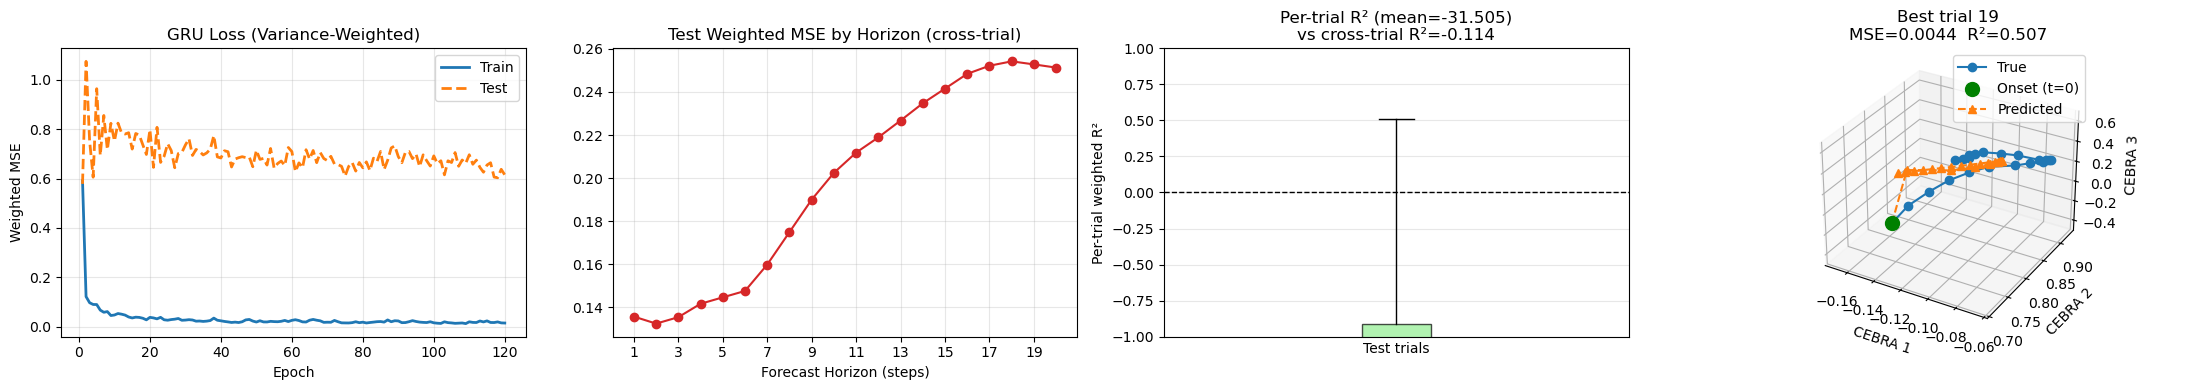

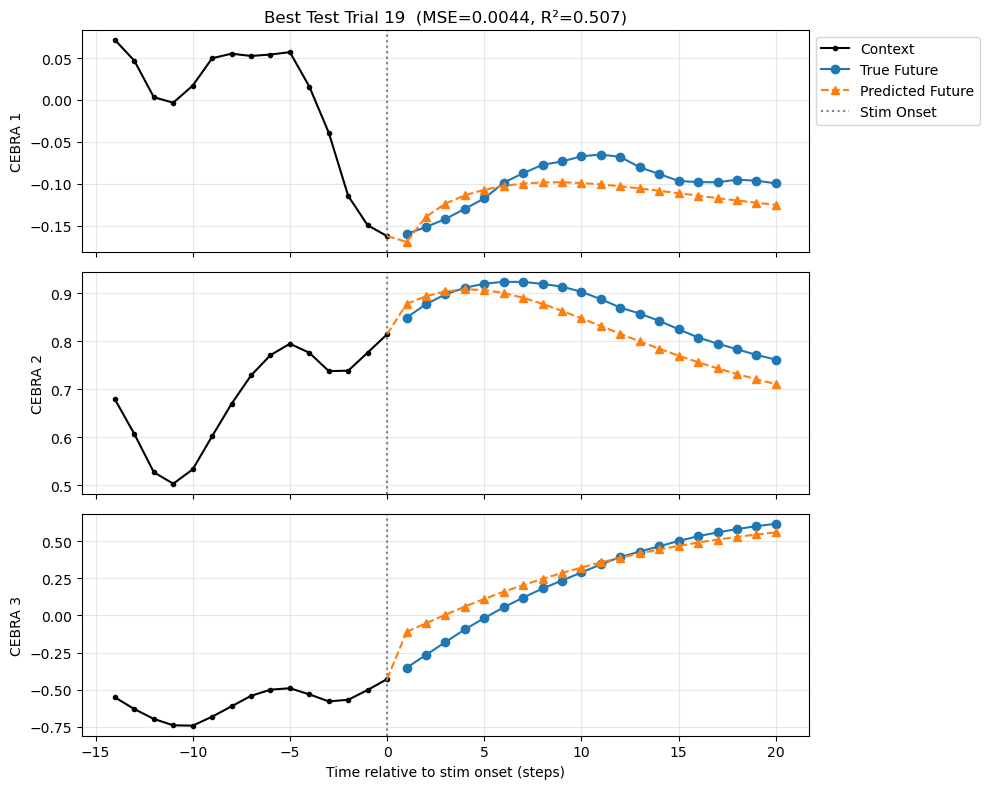

In [9]:
# --- 8. Evaluation and Plotting ---
model.eval()
with torch.no_grad():
    (context_z_t, context_v_t, future_v_t, target_z_t) = next(iter(test_loader))
    context_z_t = context_z_t.to(device)
    context_v_t = context_v_t.to(device)
    future_v_t = future_v_t.to(device)

    pred_z_t = model(context_z_t, context_v_t, future_v_t, target_z=None, teacher_forcing=0.0)

pred_z_t = pred_z_t.cpu().numpy()
target_z_t = target_z_t.numpy()

# Un-normalize for plotting and metrics
pred_z_test = pred_z_t * z_std_c + z_mean_c
target_z_test = target_z_t * z_std_c + z_mean_c

horizons = np.arange(1, horizon + 1)

# --- Horizon-wise metrics (cross-trial at each step: tracks rank-ordering across trials) ---
weighted_mse_by_h = []
weighted_r2_by_h = []
for h in range(horizon):
    y_true_h = target_z_test[:, h, :]
    y_pred_h = pred_z_test[:, h, :]
    mse_per_comp = np.mean((y_pred_h - y_true_h) ** 2, axis=0)
    weighted_mse_by_h.append(float(np.sum(component_weights * mse_per_comp)))
    r2_per_comp = np.array([
        r2_score(y_true_h[:, c], y_pred_h[:, c]) if np.var(y_true_h[:, c]) > 1e-12 else 0.0
        for c in range(d_z)
    ])
    weighted_r2_by_h.append(float(np.sum(component_weights * r2_per_comp)))

# --- Per-trial R² (across time steps within each trial → measures individual trajectory quality) ---
# Shape: (n_test, horizon, d_z) → per-trial R² per component, then weight-averaged
per_trial_r2 = np.zeros((len(test_indices), d_z))
for trial_i in range(len(test_indices)):
    for c in range(d_z):
        y_true_tc = target_z_test[trial_i, :, c]   # (horizon,)
        y_pred_tc = pred_z_test[trial_i, :, c]
        if np.var(y_true_tc) > 1e-12:
            per_trial_r2[trial_i, c] = r2_score(y_true_tc, y_pred_tc)
        else:
            per_trial_r2[trial_i, c] = 0.0
per_trial_weighted_r2 = (per_trial_r2 * component_weights).sum(axis=1)  # (n_test,)

# --- Per-trial MSE (mean over horizon, weight-averaged over components) ---
per_trial_mse_per_comp = np.mean((pred_z_test - target_z_test) ** 2, axis=1)   # (n_test, d_z)
per_trial_weighted_mse = (per_trial_mse_per_comp * component_weights).sum(axis=1)  # (n_test,)

# Select best trial by per-trial MSE
sorted_order = np.argsort(per_trial_weighted_mse)
best_local   = sorted_order[0]
best_orig    = test_indices[best_local]

print("Test trial weighted MSE (sorted best → worst):")
print(f"{'Rank':>4}  {'Test-idx':>8}  {'Trial':>7}  {'Weighted MSE':>13}  {'Weighted R²':>12}")
print("-" * 56)
for rank, local_idx in enumerate(sorted_order):
    print(f"{rank+1:>4}  {local_idx:>8}  {test_indices[local_idx]:>7}  "
          f"{per_trial_weighted_mse[local_idx]:>13.5f}  {per_trial_weighted_r2[local_idx]:>12.4f}")

print(f"\nMean per-trial weighted R²:  {per_trial_weighted_r2.mean():.4f}")
print(f"Mean cross-trial weighted R²: {np.mean(weighted_r2_by_h):.4f}  "
      f"← inflated (measures rank-ordering across trials, not per-trial accuracy)")
print(f"\nBest trial: original index {best_orig}  (MSE={per_trial_weighted_mse[best_local]:.5f}, "
      f"R²={per_trial_weighted_r2[best_local]:.4f})")

# --- Visualization ---
fig, axes = plt.subplots(1, 4, figsize=(22, 4))

# 1. Loss curve
axes[0].plot(np.arange(1, n_epochs + 1), loss_history, lw=2, label='Train')
axes[0].plot(np.arange(1, n_epochs + 1), test_loss_history, lw=2, ls='--', label='Test')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Weighted MSE')
axes[0].set_title('GRU Loss (Variance-Weighted)'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

# 2. MSE per horizon
axes[1].plot(horizons, weighted_mse_by_h, marker='o', color='tab:red')
axes[1].set_xlabel('Forecast Horizon (steps)')
axes[1].set_title('Test Weighted MSE by Horizon (cross-trial)')
axes[1].set_xticks(horizons[::2]); axes[1].grid(True, alpha=0.3)

# 3. Per-trial R² distribution (replaces misleading cross-trial R²)
axes[2].boxplot(per_trial_weighted_r2, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen', alpha=0.7))
axes[2].axhline(0, color='black', lw=1, ls='--')
axes[2].set_xlabel('Test trials'); axes[2].set_ylabel('Per-trial weighted R²')
axes[2].set_title(f'Per-trial R² (mean={per_trial_weighted_r2.mean():.3f})\nvs cross-trial R²={np.mean(weighted_r2_by_h):.3f}')
axes[2].set_xticks([]); axes[2].set_ylim(-1.0, 1.0); axes[2].grid(True, alpha=0.3)

# 4. Trajectory plot — best trial (auto-selected by per-trial MSE)
context_z_all = context_z_t.cpu().numpy() * z_std_c + z_mean_c
context_traj  = context_z_all[best_local]
last_context_pt = context_traj[-1:]

pred_traj  = pred_z_test[best_local]
true_traj  = target_z_test[best_local]
true_traj_3d = np.concatenate([last_context_pt, true_traj], axis=0)
pred_traj_3d = np.concatenate([last_context_pt, pred_traj], axis=0)

ax_3d = fig.add_subplot(1, 4, 4, projection='3d')
axes[3].axis('off')
ax_3d.plot(true_traj_3d[:, 0], true_traj_3d[:, 1], true_traj_3d[:, 2],
           color='tab:blue', marker='o', label='True')
ax_3d.scatter(*true_traj_3d[0], color='green', s=100, label='Onset (t=0)', zorder=5)
ax_3d.plot(pred_traj_3d[:, 0], pred_traj_3d[:, 1], pred_traj_3d[:, 2],
           color='tab:orange', marker='^', linestyle='--', label='Predicted')
ax_3d.set_title(f'Best trial {best_orig}\nMSE={per_trial_weighted_mse[best_local]:.4f}  R²={per_trial_weighted_r2[best_local]:.3f}')
ax_3d.set_xlabel('CEBRA 1'); ax_3d.set_ylabel('CEBRA 2'); ax_3d.set_zlabel('CEBRA 3')
ax_3d.legend()

plt.tight_layout()
plt.show()

# --- 1D component time series for best trial ---
hist_len = 15
hist_ts  = np.arange(-hist_len + 1, 1)
fut_ts   = np.arange(1, horizon + 1)

fig_comps, axes_comps = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for i in range(3):
    axes_comps[i].plot(hist_ts, context_traj[-hist_len:, i], color='black', marker='.', label='Context' if i == 0 else "")
    axes_comps[i].plot(fut_ts, true_traj[:, i], color='tab:blue', marker='o', label='True Future' if i == 0 else "")
    axes_comps[i].plot([0, 1], [context_traj[-1, i], pred_traj[0, i]], color='tab:orange', linestyle='--')
    axes_comps[i].plot(fut_ts, pred_traj[:, i], color='tab:orange', marker='^', linestyle='--', label='Predicted Future' if i == 0 else "")
    axes_comps[i].axvline(0, color='gray', linestyle=':', label='Stim Onset' if i == 0 else "")
    axes_comps[i].set_ylabel(f'CEBRA {i+1}')
    axes_comps[i].grid(True, alpha=0.3)

axes_comps[0].set_title(f'Best Test Trial {best_orig}  '
                        f'(MSE={per_trial_weighted_mse[best_local]:.4f}, R²={per_trial_weighted_r2[best_local]:.3f})')
axes_comps[0].legend(loc='upper left', bbox_to_anchor=(1, 1))
axes_comps[-1].set_xlabel('Time relative to stim onset (steps)')
plt.tight_layout()
plt.show()
